In [26]:
# Initialization
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

class df_data():
  def __init__(self):
    self.gentoo = pd.read_csv('../data/gentoo_bugs_before_2012.csv')
    self.kde = pd.read_csv('../data/kde_bugs_before_2012.csv')
    self.suse = pd.read_csv('../data/suse_bugs_before_2012.csv')

data = df_data()

print(data.kde.columns)

def convert_date_column_to_year(df):
   df['creation_time'] = pd.DatetimeIndex(df['creation_time']).year
   return df

data.gentoo = convert_date_column_to_year(data.gentoo)
data.kde = convert_date_column_to_year(data.kde)
data.suse = convert_date_column_to_year(data.suse)

print(f"Gentoo Years: {data.gentoo['creation_time'].unique()}")
print(f"KDE Years:    {data.kde['creation_time'].unique()}")
print(f"Suse Years:   {data.suse['creation_time'].unique()}")

Index(['last_change_time', 'assigned_to', 'status', 'creation_time', 'creator',
       'severity', 'product', 'assigned_to_detail', 'id', 'priority',
       'component', 'creator_detail', 'resolution', 'dupe_of'],
      dtype='object')
Gentoo Years: [2002 2003 2004 2005 2006 2007 2008 2009 2010 2011]
KDE Years:    [1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011]
Suse Years:   [2004 2005 2001 2002 2003 1998 1997 1999 2006 2007 2008 2009 2010 2011]


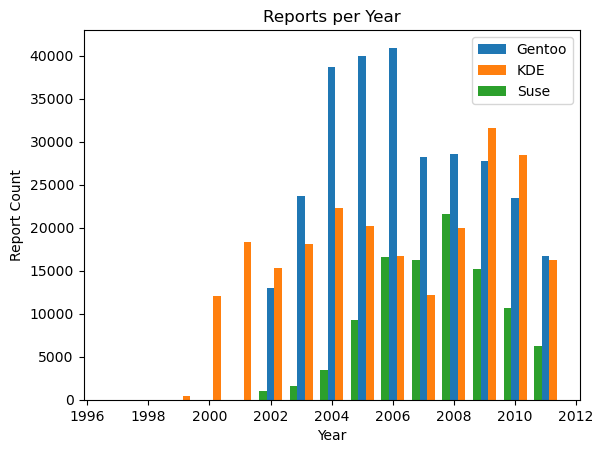

In [27]:
# Figure 1 Block
def get_tickets_per_year(df): 
    # Oldest ticket is 1997, latest is 2011   
    full_year_list = [d for d in df['creation_time']]
    year_list, counts = np.unique(full_year_list, return_counts=True)
  
    return year_list, counts

def create_tickets_per_year_plot(data):
  gentoo_years, gentoo_counts = get_tickets_per_year(data.gentoo)
  kde_years, kde_counts = get_tickets_per_year(data.kde)
  suse_years, suse_counts = get_tickets_per_year(data.suse)  
  
  fig, ax = plt.subplots()
  w = 0.25
  ax.bar(gentoo_years, gentoo_counts, width=w, label='Gentoo')
  ax.bar(kde_years + w, kde_counts, width=w, label='KDE')
  ax.bar(suse_years - w, suse_counts, width=w, label='Suse')  
  ax.set_title('Reports per Year')
  ax.set_xlabel('Year')
  ax.set_ylabel('Report Count')
  ax.legend()
  plt.show()

create_tickets_per_year_plot(data)  

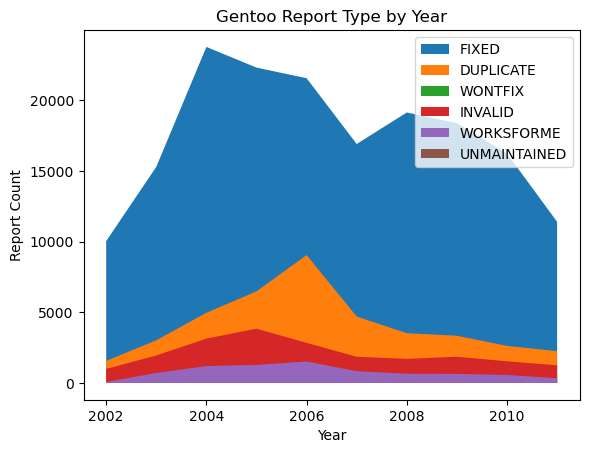

In [48]:
# Figure 2 Block
# X Year, Y Percent, Line = Report Type, 1 Plot per Gentoo, KDE, Suse

def get_each_report_type_count(df):
  report_type_counts = {}

  for resolution in df['resolution'].unique():
    report_type_counts[resolution] = len(df.loc[(df['resolution'] == resolution)])  

  for key in report_type_counts.keys():
    print(f"{key}: {report_type_counts[key]}")
  
# print("GENTOO")
# get_each_report_type_count(data.gentoo)

# print("\nKDE")
# get_each_report_type_count(data.kde)

# print("\nSUSE")
# get_each_report_type_count(data.suse)

def get_report_type_per_year(df):
  report_types_per_year = defaultdict(dict)

  years, counts = get_tickets_per_year(df)

  for year in years:
    sub_frame = df.loc[(df['creation_time'] == year)]   
    for resolution in sub_frame['resolution'].unique():
      report_types_per_year[resolution][year] = len(sub_frame.loc[(sub_frame['resolution'] == resolution)])
  
  return report_types_per_year

gentoo_years_report_type_count = get_report_type_per_year(data.gentoo)
kde_years_report_type_count = get_report_type_per_year(data.kde)
suse_years_report_type_count = get_report_type_per_year(data.suse)

def plot_report_type_per_year(report_type_dict, title):
  resolutions = ['FIXED', 'DUPLICATE', 'WONTFIX', 'INVALID', 'WORKSFORME', 'UNMAINTAINED']
  for resolution in resolutions:
    x = report_type_dict[resolution].keys()
    y = []
    for year in x:
      y.append(report_type_dict[resolution][year])
    plt.fill_between(x, y, label=resolution)
  plt.xlabel("Year")
  plt.ylabel("Report Count")
  plt.title(title)
  plt.legend()
  plt.plot()    
    

plot_report_type_per_year(gentoo_years_report_type_count, "Gentoo Report Type by Year")

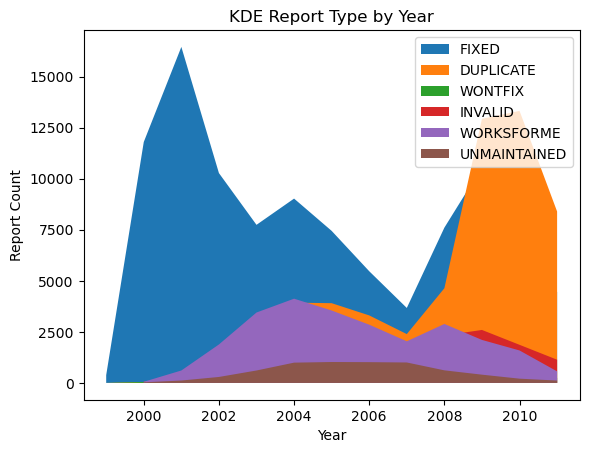

In [47]:
plot_report_type_per_year(kde_years_report_type_count, "KDE Report Type by Year") 

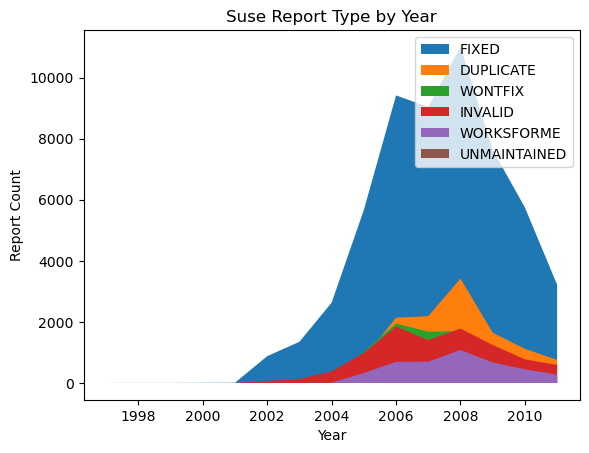

In [49]:
plot_report_type_per_year(suse_years_report_type_count, "Suse Report Type by Year") 